In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("carlthome/gtzan-genre-collection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/gtzan-genre-collection


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import random
import librosa, IPython
import librosa.display as lplt
seed = 12
np.random.seed(seed)

In [ ]:
import kagglehub
andradaolteanu_gtzan_dataset_music_genre_classification_path = kagglehub.dataset_download('andradaolteanu/gtzan-dataset-music-genre-classification')

print('Data source import complete.')


Data source import complete.


In [ ]:
df = pd.read_csv('/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv')
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [ ]:
print("Dataset has",df.shape)
print("Count of Positive and Negative samples")
df.label.value_counts().reset_index()

Dataset has (9990, 60)
Count of Positive and Negative samples


,label,count
0,blues,1000
1,jazz,1000
2,pop,1000
3,reggae,1000
4,metal,1000
5,disco,999
6,classical,998
7,hiphop,998
8,rock,998
9,country,997


In [ ]:
audio_fp = '/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/blues/blues.00000.wav'
audio_data, sr = librosa.load(audio_fp)
audio_data, _ = librosa.effects.trim(audio_data)

In [ ]:
# play sample file
IPython.display.Audio(audio_data, rate=sr)

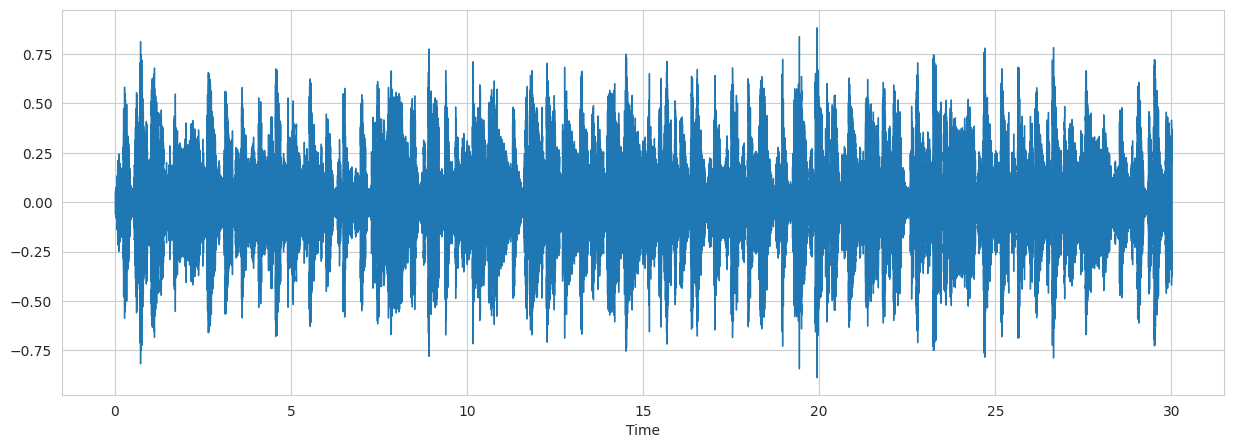

In [ ]:

# plot sample file
plt.figure(figsize=(15,5))
librosa.display.waveshow(audio_data, sr=sr) # Changed lplt.waveplot to librosa.display.waveshow and added sr
plt.show()

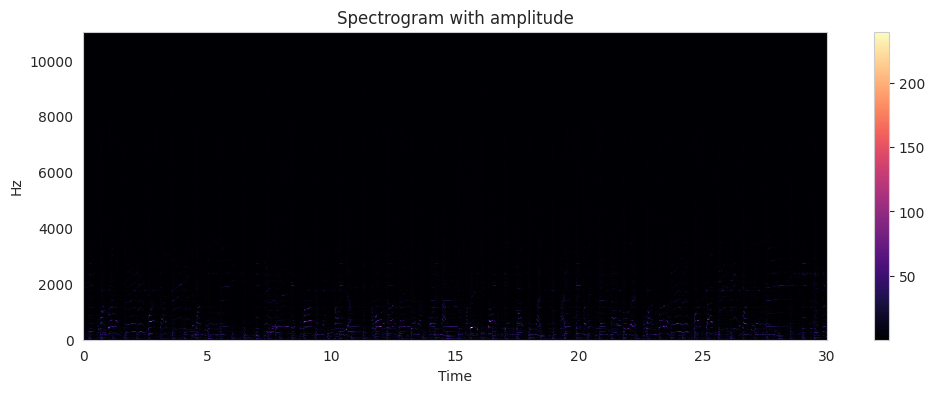

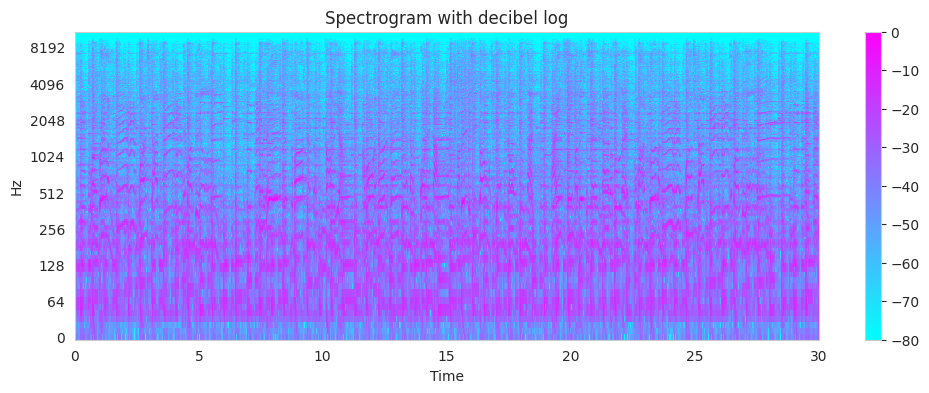

In [ ]:
# Default FFT window size
n_fft = 2048 # window size
hop_length = 512 # window hop length for STFT

stft = librosa.stft(audio_data, n_fft=n_fft, hop_length=hop_length)
stft_db = librosa.amplitude_to_db(stft, ref=np.max)

plt.figure(figsize=(12,4))
lplt.specshow(stft, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram with amplitude")
plt.show()

plt.figure(figsize=(12,4))
lplt.specshow(stft_db, sr=sr, x_axis='time', y_axis='log', cmap='cool')
plt.colorbar()
plt.title("Spectrogram with decibel log")
plt.show()

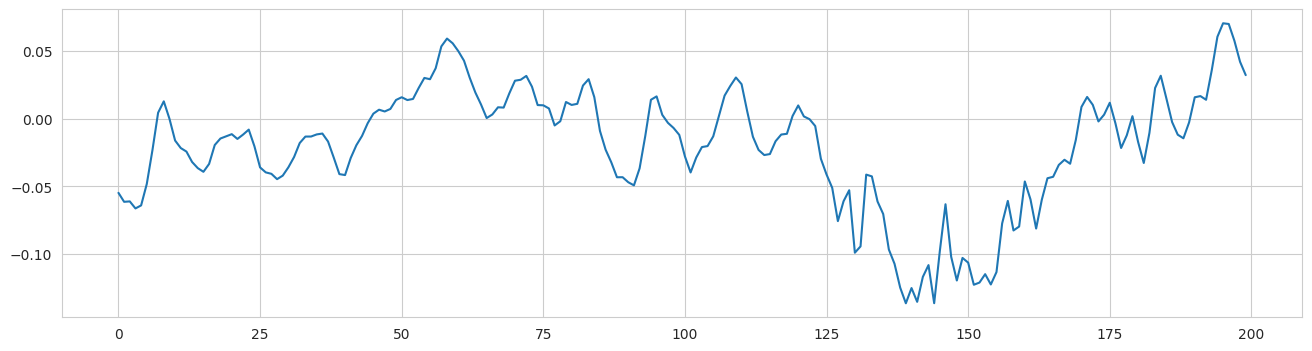

In [ ]:
# plot zoomed audio wave
start = 1000
end = 1200
plt.figure(figsize=(16,4))
plt.plot(audio_data[start:end])
plt.show()

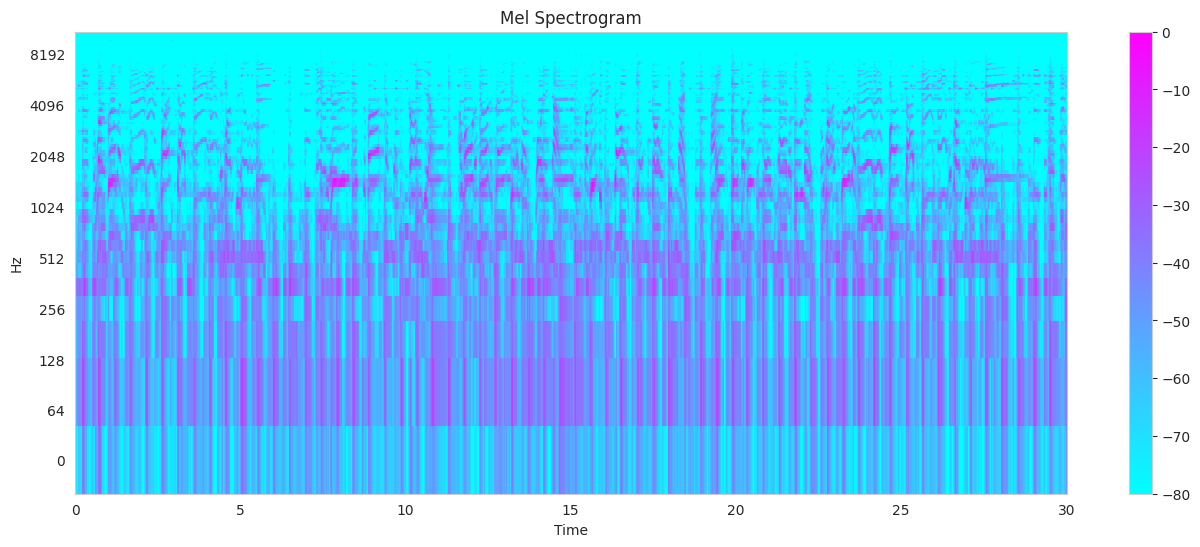

In [ ]:
import librosa
import librosa.display as lplt
import matplotlib.pyplot as plt
import numpy as np

# Assuming audio_data and sr are already loaded

# Calculate mel spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio_data, sr=sr)  # Pass audio_data as keyword argument 'y'
mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)

# Display the mel spectrogram
plt.figure(figsize=(16, 6))
lplt.specshow(mel_spec_db, sr=sr, hop_length=512, x_axis='time', y_axis='log', cmap='cool')
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

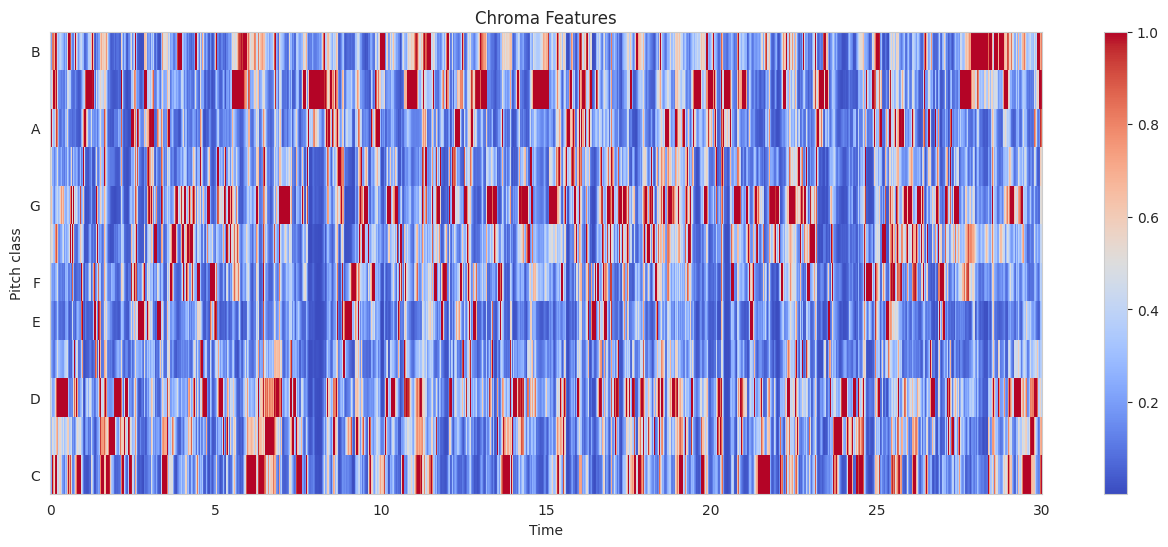

In [ ]:
chroma = librosa.feature.chroma_stft(y=audio_data, sr=sr) # Changed to pass audio_data as keyword argument 'y'
plt.figure(figsize=(16,6))
lplt.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar()
plt.title("Chroma Features")
plt.show()

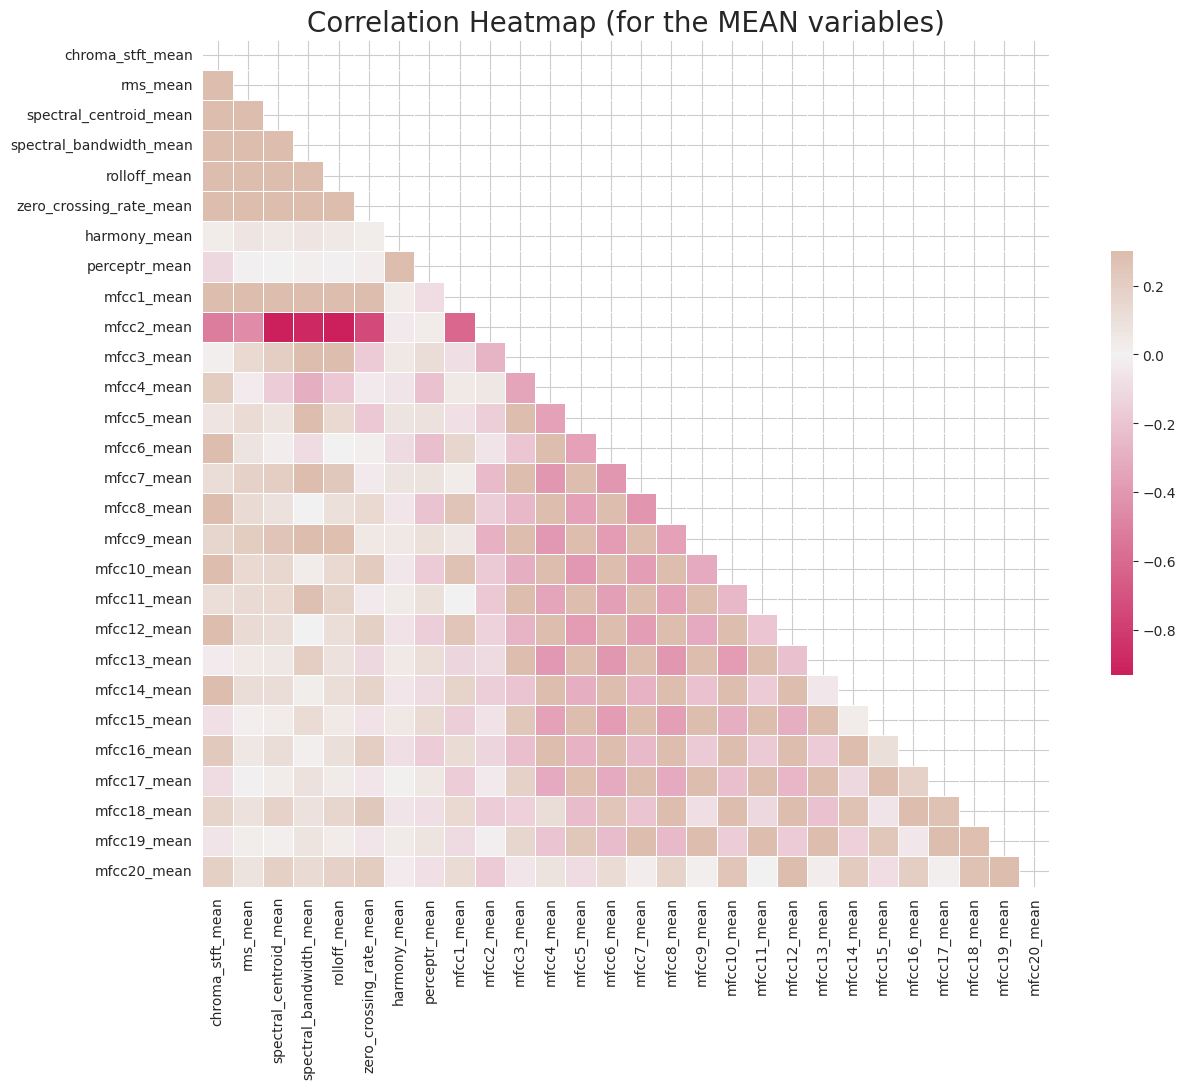

In [ ]:
# Computing the Correlation Matrix
spike_cols = [col for col in df.columns if 'mean' in col]
corr = df[spike_cols].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=np.bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 11));

# Generate a custom diverging colormap
cmap = sns.diverging_palette(0, 25, as_cmap=True, s = 90, l = 45, n = 5)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Correlation Heatmap (for the MEAN variables)', fontsize = 20)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10);
plt.savefig("Corr_Heatmap.png")

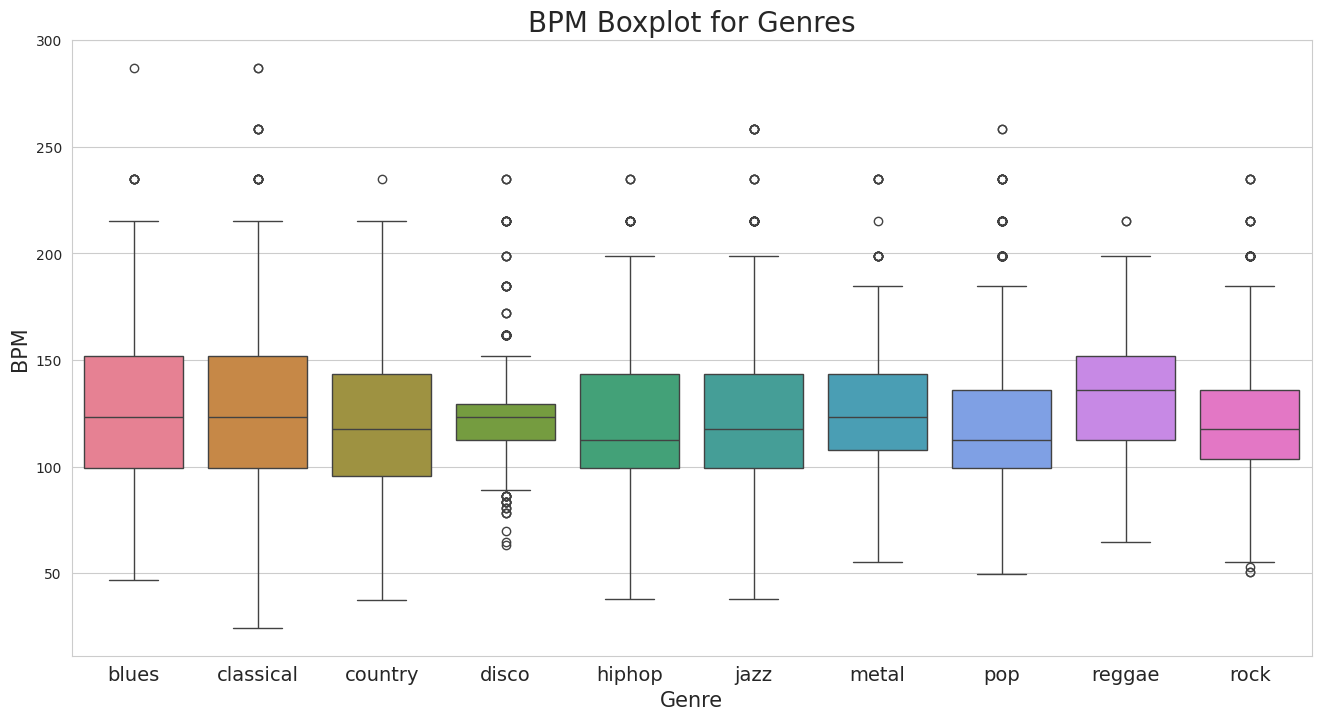

In [ ]:
x = df[["label", "tempo"]]

fig, ax = plt.subplots(figsize=(16, 8));
sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');

plt.title('BPM Boxplot for Genres', fontsize = 20)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Genre", fontsize = 15)
plt.ylabel("BPM", fontsize = 15)
plt.savefig("BPM_Boxplot.png")

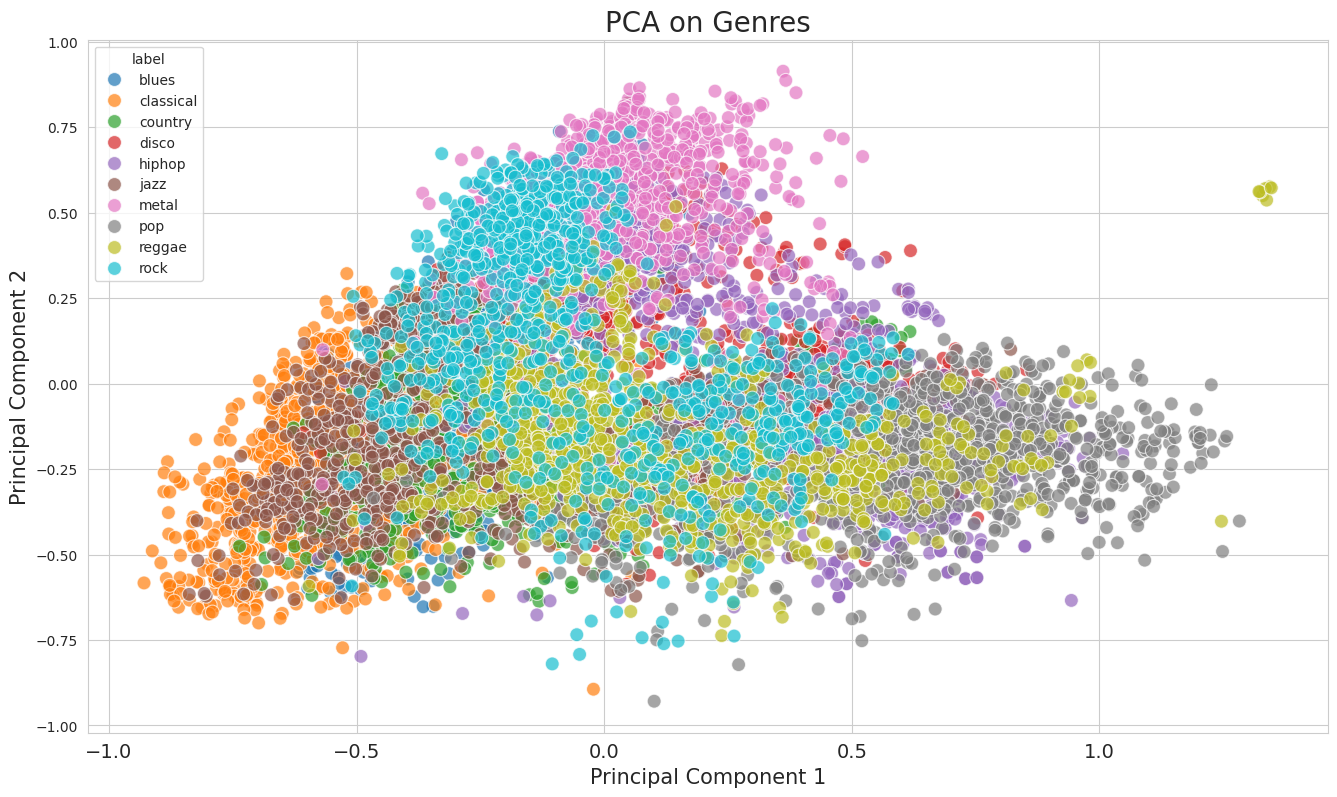

In [ ]:
data = df.iloc[0:, 1:]
y = data['label']
X = data.loc[:, data.columns != 'label']

# normalize
cols = X.columns
min_max_scaler = skp.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(np_scaled, columns = cols)

# Top 2 pca components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents, columns = ['pc1', 'pc2'])

# concatenate with target label
finalDf = pd.concat([principalDf, y], axis = 1)

plt.figure(figsize = (16, 9))
sns.scatterplot(x = "pc1", y = "pc2", data = finalDf, hue = "label", alpha = 0.7, s = 100);

plt.title('PCA on Genres', fontsize = 20)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
plt.savefig("PCA_Scattert.png")

In [ ]:
# find all columns with any NA values
print("Columns with NA values are",list(df.columns[df.isnull().any()]))

Columns with NA values are []


In [ ]:
# map labels to index
label_index = dict()
index_label = dict()
for i, x in enumerate(df.label.unique()):
    label_index[x] = i
    index_label[i] = x
print(label_index)
print(index_label)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}
{0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}


In [ ]:
# update labels in df to index
df.label = [label_index[l] for l in df.label]

In [ ]:
# remove irrelevant columns
df.drop(['filename', 'length'], axis=1, inplace=True) # Changed df_shuffle to df
df_y = df.pop('label') # Changed df_shuffle to df
df_X = df # Changed df_shuffle to df

In [ ]:
# split into train dev and test
X_train, df_test_valid_X, y_train, df_test_valid_y = skms.train_test_split(df_X, df_y, train_size=0.7, random_state=seed, stratify=df_y)
X_dev, X_test, y_dev, y_test = skms.train_test_split(df_test_valid_X, df_test_valid_y, train_size=0.66, random_state=seed, stratify=df_test_valid_y)

In [ ]:
print(f"Train set has {X_train.shape[0]} records out of {len(df)} which is {round(X_train.shape[0]/len(df)*100)}%") # Changed df_shuffle to df
print(f"Dev set has {X_dev.shape[0]} records out of {len(df)} which is {round(X_dev.shape[0]/len(df)*100)}%") # Changed df_shuffle to df
print(f"Test set has {X_test.shape[0]} records out of {len(df)} which is {round(X_test.shape[0]/len(df)*100)}%") # Changed df_shuffle to df

Train set has 6993 records out of 9990 which is 70%
Dev set has 1978 records out of 9990 which is 20%
Test set has 1019 records out of 9990 which is 10%


In [ ]:
print(y_train.value_counts()[0]/y_train.shape[0]*100)
print(y_dev.value_counts()[0]/y_dev.shape[0]*100)
print(y_test.value_counts()[0]/y_test.shape[0]*100)

10.01001001001001
10.010111223458038
10.009813542688912


In [ ]:
scaler = skp.StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_dev = pd.DataFrame(scaler.transform(X_dev), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

In [ ]:
import tensorflow as tf
print("TF version:-", tf.__version__)
import keras as k
tf.random.set_seed(seed)

TF version:- 2.18.0


In [ ]:
ACCURACY_THRESHOLD = 0.94

class myCallback(k.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy') > ACCURACY_THRESHOLD):
            print("\n\nStopping training as we have reached %2.2f%% accuracy!" %(ACCURACY_THRESHOLD*100))
            self.model.stop_training = True

def trainModel(model, epochs, optimizer):
    batch_size = 128
    callback = myCallback()
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics='accuracy'
    )
    return model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=epochs,
                     batch_size=batch_size, callbacks=[callback])

def plotHistory(history):
    print("Max. Validation Accuracy",max(history.history["val_accuracy"]))
    pd.DataFrame(history.history).plot(figsize=(12,6))
    plt.show()


In [ ]:
def trainModel(model, epochs, optimizer):
    batch_size = 128
    callback = myCallback()
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'] # Changed 'accuracy' to ['accuracy']
    )
    return model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=epochs,
                     batch_size=batch_size, callbacks=[callback])

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3843 - loss: 1.7942 - val_accuracy: 0.6385 - val_loss: 1.0543
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6721 - loss: 0.9382 - val_accuracy: 0.7199 - val_loss: 0.8186
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7570 - loss: 0.7141 - val_accuracy: 0.7553 - val_loss: 0.7237
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7971 - loss: 0.5910 - val_accuracy: 0.7806 - val_loss: 0.6623
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8291 - loss: 0.5017 - val_accuracy: 0.7983 - val_loss: 0.6134
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8545 - loss: 0.4275 - val_accuracy: 0.8114 - val_loss: 0.5730
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8817 - loss: 0.3622 - val_accuracy: 0.8256 - val_loss: 0.5405
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9021 - loss: 0.3067 - val_accuracy: 0.8276 - val_loss

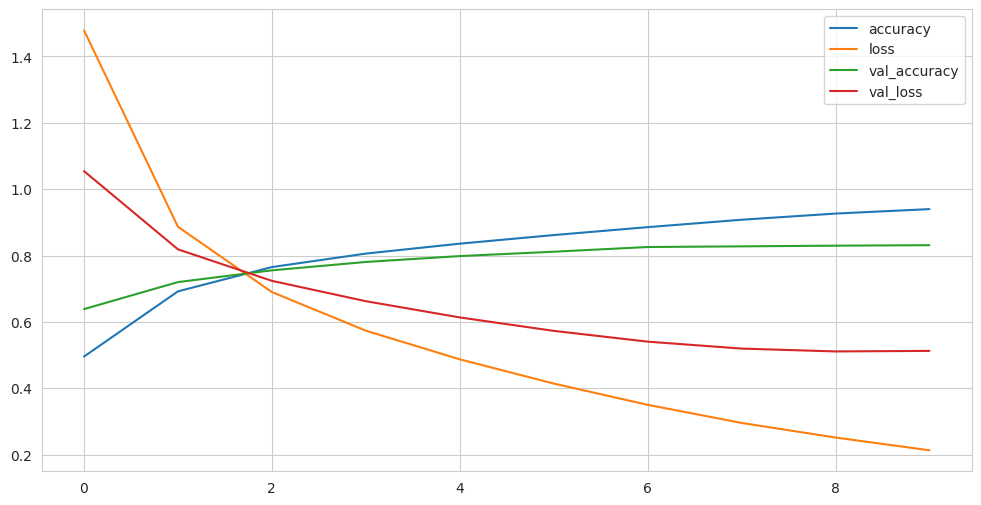

In [ ]:
# Assuming you've defined your model as 'model_1' and chosen an optimizer like 'adam'
import tensorflow as tf
import keras as k
from tensorflow import keras

# Assuming 'model_1' is your defined Keras model
model_1 = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)), # Input layer with 256 units and ReLU activation
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 units and ReLU activation
    keras.layers.Dense(64, activation='relu'),   # Hidden layer with 64 units and ReLU activation
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 units (for 10 genres) and softmax activation
])

# Choose an optimizer, e.g., 'adam'
optimizer = 'adam'

# Train the model and store the history
model_1_history = trainModel(model_1, epochs=10, optimizer=optimizer) # Assuming 10 epochs, adjust as needed


plotHistory(model_1_history)

In [ ]:
model_2 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_2.summary())
model_2_history = trainModel(model=model_2, epochs=100, optimizer='adam')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.3206 - loss: 1.8920 - val_accuracy: 0.6259 - val_loss: 1.1001
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5911 - loss: 1.1738 - val_accuracy: 0.7012 - val_loss: 0.8646
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6723 - loss: 0.9418 - val_accuracy: 0.7427 - val_loss: 0.7490
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7284 - loss: 0.8057 - val_accuracy: 0.7700 - val_loss: 0.6805
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7587 - loss: 0.7060 - val_accuracy: 0.7872 - val_loss: 0.6262
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7924 - loss: 0.6248 - val_accuracy: 0.8064 - val_loss: 0.5704
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8071 - loss: 0.5702 - val_accuracy: 0.8104 - val_loss: 0.5693
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8262 - loss: 0.5157 - val_accuracy: 0.83

Max. Validation Accuracy 0.9226491451263428


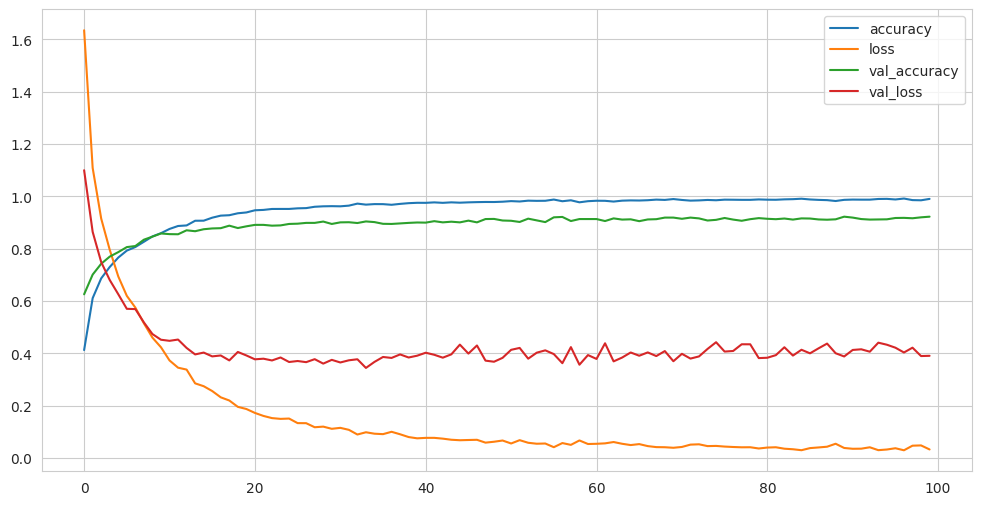

In [ ]:
plotHistory(model_2_history)

In [ ]:
model_3 = k.models.Sequential([
    k.layers.Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.2),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),

    k.layers.Dense(10, activation='softmax'),
])
print(model_3.summary())
model_3_history = trainModel(model=model_3, epochs=700, optimizer='sgd')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,826 (792.29 KB)

 Trainable params: 202,826 (792.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.1195 - loss: 2.3174 - val_accuracy: 0.3185 - val_loss: 2.1865
Epoch 2/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2115 - loss: 2.1965 - val_accuracy: 0.3670 - val_loss: 2.0526
Epoch 3/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2873 - loss: 2.0778 - val_accuracy: 0.3802 - val_loss: 1.9075
Epoch 4/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3417 - loss: 1.9481 - val_accuracy: 0.3964 - val_loss: 1.7662
Epoch 5/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3674 - loss: 1.8321 - val_accuracy: 0.4206 - val_loss: 1.6477
Epoch 6/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3725 - loss: 1.7297 - val_accuracy: 0.4469 - val_loss: 1.5516
Epoch 7/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4062 - loss: 1.6701 - val_accuracy: 0.4671 - val_loss: 1.4773
Epoch 8/700
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4277 - loss: 1.5714 - val_accuracy: 0.

Max. Validation Accuracy 0.9125379323959351


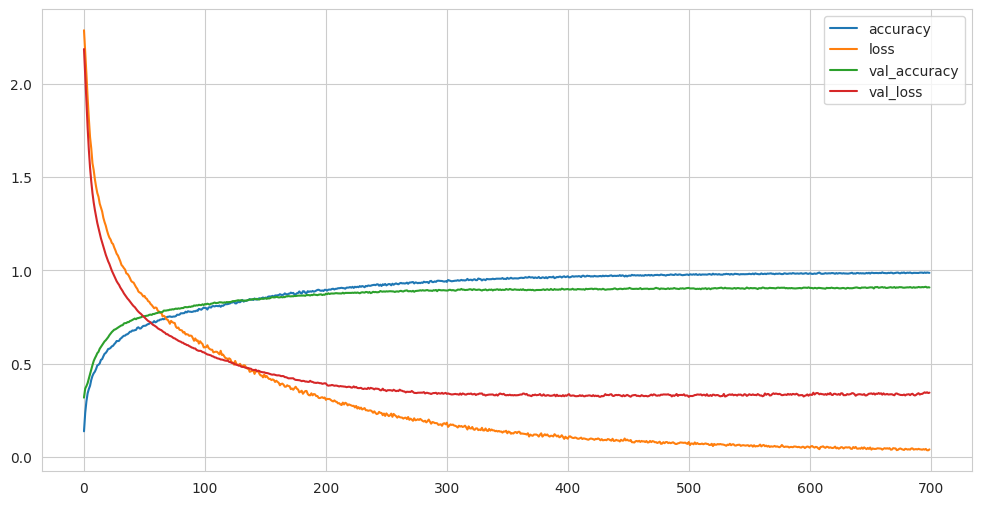

In [ ]:
plotHistory(model_3_history)

In [ ]:
model_4 = k.models.Sequential([
    k.layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    k.layers.Dropout(0.3),

    k.layers.Dense(512, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.3),

    k.layers.Dense(10, activation='softmax'),
])
print(model_4.summary())
model_4_history = trainModel(model=model_4, epochs=500, optimizer='rmsprop')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 1024)           │        59,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,322 (2.89 MB)

 Trainable params: 757,322 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.2840 - loss: 1.9383 - val_accuracy: 0.6026 - val_loss: 1.1733
Epoch 2/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5393 - loss: 1.3036 - val_accuracy: 0.6744 - val_loss: 0.9665
Epoch 3/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6499 - loss: 1.0530 - val_accuracy: 0.7305 - val_loss: 0.8180
Epoch 4/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7009 - loss: 0.9421 - val_accuracy: 0.7568 - val_loss: 0.7063
Epoch 5/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7268 - loss: 0.8146 - val_accuracy: 0.7664 - val_loss: 0.6772
Epoch 6/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7605 - loss: 0.7274 - val_accuracy: 0.7887 - val_loss: 0.6355
Epoch 7/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7948 - loss: 0.6450 - val_accuracy: 0.8054 - val_loss: 0.5959
Epoch 8/500
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8075 - loss: 0.5972 - val_accuracy: 0.81

Max. Validation Accuracy 0.9403437972068787


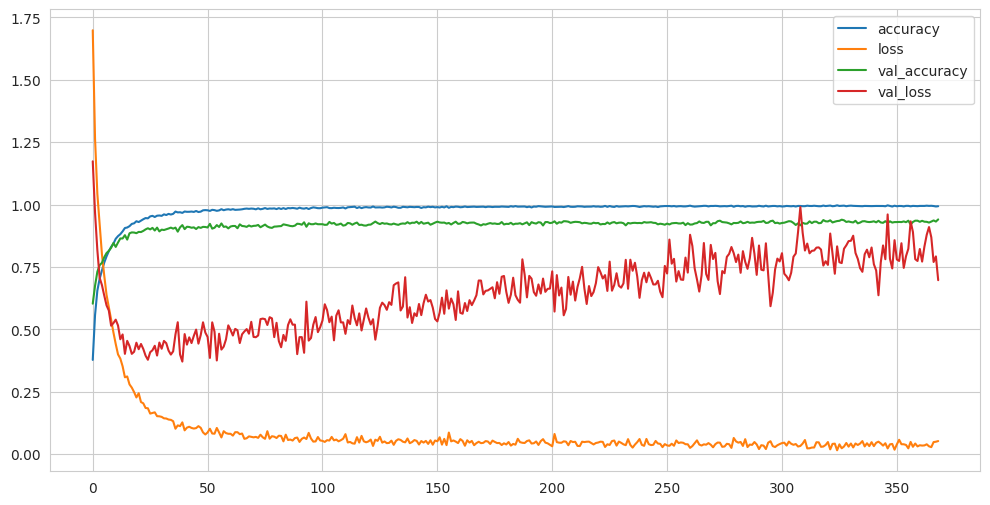

In [ ]:
plotHistory(model_4_history)

In [ ]:
test_loss, test_acc  = model_4.evaluate(X_test, y_test, batch_size=128)
print("The test Loss is :",test_loss)
print("\nThe Best test Accuracy is :",test_acc*100)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9265 - loss: 1.0625
The test Loss is : 1.066441297531128

The Best test Accuracy is : 92.83611178398132


In [ ]:

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare the data
df = pd.read_csv('/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv')
X = df.drop(columns=['filename', 'label'])
y = df['label']

# Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split and scale
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=12, stratify=y_encoded)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=12, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_dev = scaler.transform(X_dev)
X_test = scaler.transform(X_test)

# One-hot encode labels
def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

y_train_oh = one_hot(y_train, 10)

# Initialize weights
n_samples, n_features = X_train.shape
n_classes = 10
W = np.zeros((n_features, n_classes))
b = np.zeros((1, n_classes))

# Hyperparameters
lr = 0.01
epochs = 100
momentum = 0.9
batch_size = 64

# Initialize momentum terms
v_W = np.zeros_like(W)
v_b = np.zeros_like(b)

# Softmax and loss
def softmax(z):
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e_z / np.sum(e_z, axis=1, keepdims=True)

def cross_entropy(preds, targets):
    return -np.mean(np.sum(targets * np.log(preds + 1e-15), axis=1))

# Training loop with SGD + momentum
for epoch in range(epochs):
    permutation = np.random.permutation(n_samples)
    X_shuffled = X_train[permutation]
    y_shuffled = y_train_oh[permutation]

    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        # Forward pass
        logits = np.dot(X_batch, W) + b
        probs = softmax(logits)
        loss = cross_entropy(probs, y_batch)

        # Gradients
        dW = np.dot(X_batch.T, (probs - y_batch)) / X_batch.shape[0]
        db = np.sum(probs - y_batch, axis=0, keepdims=True) / X_batch.shape[0]

        # Momentum update
        v_W = momentum * v_W - lr * dW
        v_b = momentum * v_b - lr * db

        W += v_W
        b += v_b

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Evaluate on test set
logits_test = np.dot(X_test, W) + b
preds_test = np.argmax(softmax(logits_test), axis=1)
acc = accuracy_score(y_test, preds_test)
print(f"Test Accuracy: {acc:.4f}")


Epoch 0, Loss: 1.0780
Epoch 10, Loss: 0.6330
Epoch 20, Loss: 0.9977
Epoch 30, Loss: 0.7195
Epoch 40, Loss: 0.6634
Epoch 50, Loss: 0.9067
Epoch 60, Loss: 0.7578
Epoch 70, Loss: 1.5772
Epoch 80, Loss: 0.7409
Epoch 90, Loss: 0.5482
Test Accuracy: 0.7145


In [ ]:
# add the stocastic gradient decent algorithmn to its classification

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn.metrics as skm
import sklearn.model_selection as skms
import sklearn.preprocessing as skp
import random
import librosa, IPython
import librosa.display as lplt
import librosa
from sklearn.decomposition import PCA
import tensorflow as tf
import keras as k
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ... (rest of your existing code)

# Prepare the data (as you have already done)
# ...

# Initialize weights
n_samples, n_features = X_train.shape
n_classes = 10
W = np.zeros((n_features, n_classes))
b = np.zeros((1, n_classes))

# Hyperparameters
lr = 0.01  # Learning rate
epochs = 100  # Number of epochs
batch_size = 64  # Batch size


# Softmax and loss functions (as you have already defined)
# ...


# Training loop with SGD
for epoch in range(epochs):
    permutation = np.random.permutation(n_samples)
    X_shuffled = X_train[permutation]
    y_shuffled = y_train_oh[permutation]

    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        # Forward Pass
        z = np.dot(X_batch,W) + b
        y_pred = softmax(z)
        loss = cross_entropy(y_pred, y_batch)

        # Backpropagation
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T,dz) / batch_size
        db = np.sum(dz, axis = 0 , keepdims = True) / batch_size

        # Update weights using Stochastic Gradient Descent
        W -= lr * dW
        b -= lr * db


    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Evaluate on the test set
logits_test = np.dot(X_test,W)+b
preds_test = np.argmax(softmax(logits_test),axis=1)

# Assuming y_test contains the true labels
accuracy = accuracy_score(y_test, preds_test)

print(f"Test Accuracy: {accuracy:.4f}")


Epoch 0, Loss: 1.7834
Epoch 10, Loss: 1.0202
Epoch 20, Loss: 1.5004
Epoch 30, Loss: 0.9339
Epoch 40, Loss: 0.7558
Epoch 50, Loss: 0.7052
Epoch 60, Loss: 0.9572
Epoch 70, Loss: 0.8361
Epoch 80, Loss: 0.9606
Epoch 90, Loss: 0.6617
Test Accuracy: 0.6985
